# 02 - Distribution Coefficients: pH, Temperature, and Concentration Effects

This notebook explores how the distribution coefficients for Nd and Dy vary with operating conditions using difflow_ree.

## Overview

The distribution coefficient D is the key parameter controlling separation. Understanding how D changes with pH, temperature, and extractant concentration is essential for process design.

**Key questions:**
- How does pH affect D_Nd and D_Dy?
- What is the separation factor and how does it vary?
- How sensitive is D to temperature and [D2EHPA]?

In [1]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import difflow_ree for REE distribution coefficients
from difflow_ree.equilibrium.distribution import REEDistribution
from difflow_ree.database import get_extractant

plt.style.use('seaborn-v0_8-whitegrid')

# Create distribution model
dist = REEDistribution(
    extractant="D2EHPA",
    elements=("Nd", "Dy"),
    concentration=0.5,
)

W0000 00:00:1767574787.081818 18440462 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767574787.088752 18440462 service.cc:145] XLA service 0x6000038d4c00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767574787.088764 18440462 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767574787.089685 18440462 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767574787.089694 18440462 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


## 1. Distribution Coefficients vs pH

pH is the most important operating variable. The extraction reaction releases H+ ions:

$$REE^{3+}_{aq} + 3(HA)_{2,org} \rightleftharpoons REE(HA_2)_{3,org} + 3H^+_{aq}$$

Higher pH shifts equilibrium toward extraction (higher D).

Saved: fig2_distribution_coeffs.png/pdf


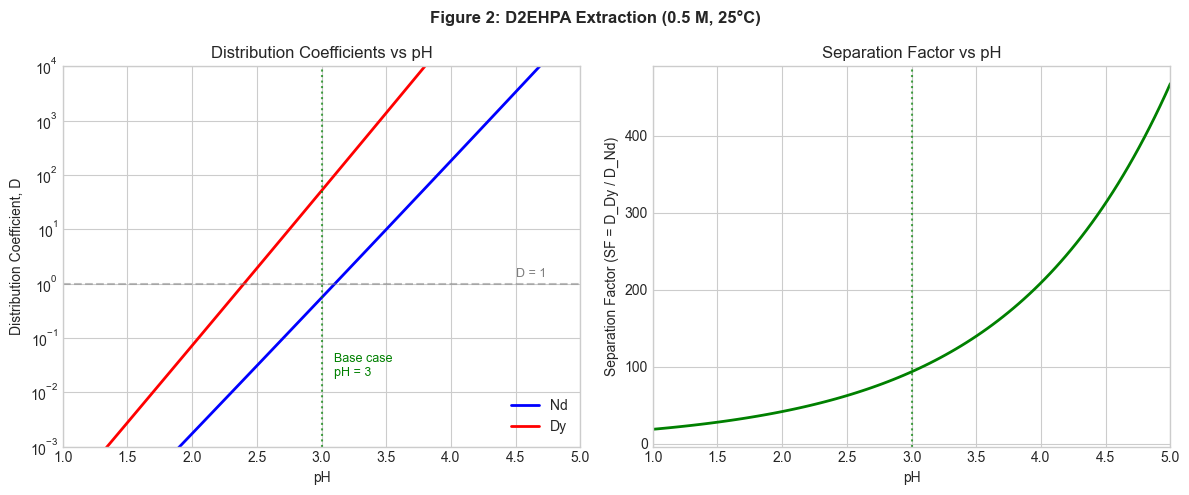

At pH = 3.0:
  D_Nd = 0.49
  D_Dy = 44.9
  SF = 91.8


In [2]:
# Calculate D vs pH
pH_vals = np.linspace(1.0, 5.0, 100)
T_ref = 298.15

D_Nd = np.array([float(dist.get_D('Nd', pH, T_ref)) for pH in pH_vals])
D_Dy = np.array([float(dist.get_D('Dy', pH, T_ref)) for pH in pH_vals])
SF = D_Dy / D_Nd

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: D vs pH (log scale)
ax1 = axes[0]
ax1.semilogy(pH_vals, D_Nd, 'b-', linewidth=2, label='Nd')
ax1.semilogy(pH_vals, D_Dy, 'r-', linewidth=2, label='Dy')
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax1.text(4.5, 1.3, 'D = 1', fontsize=9, color='gray')
ax1.axvline(x=3.0, color='green', linestyle=':', alpha=0.7)
ax1.text(3.1, 0.02, 'Base case\npH = 3', fontsize=9, color='green')
ax1.set_xlabel('pH')
ax1.set_ylabel('Distribution Coefficient, D')
ax1.set_title('Distribution Coefficients vs pH')
ax1.legend(loc='lower right')
ax1.set_xlim(1, 5)
ax1.set_ylim(0.001, 10000)

# Right: Separation Factor vs pH
ax2 = axes[1]
ax2.plot(pH_vals, SF, 'g-', linewidth=2)
ax2.axvline(x=3.0, color='green', linestyle=':', alpha=0.7)
ax2.set_xlabel('pH')
ax2.set_ylabel('Separation Factor (SF = D_Dy / D_Nd)')
ax2.set_title('Separation Factor vs pH')
ax2.set_xlim(1, 5)

plt.suptitle('Figure 2: D2EHPA Extraction (0.5 M, 25°C)', fontsize=12, fontweight='bold')
plt.tight_layout()

# Save figure
fig.savefig('../manuscript/figures/fig2_distribution_coeffs.png', dpi=300, bbox_inches='tight')
fig.savefig('../manuscript/figures/fig2_distribution_coeffs.pdf', bbox_inches='tight')
print("Saved: fig2_distribution_coeffs.png/pdf")

plt.show()

# Print values at base case
idx_3 = np.argmin(np.abs(pH_vals - 3.0))
print(f"At pH = 3.0:")
print(f"  D_Nd = {D_Nd[idx_3]:.2f}")
print(f"  D_Dy = {D_Dy[idx_3]:.1f}")
print(f"  SF = {SF[idx_3]:.1f}")

## 2. D Values at Selected pH Points

In [3]:
# Table of D values at selected pH
selected_pH = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

table_data = []
for pH in selected_pH:
    D_Nd_val = float(dist.get_D('Nd', pH, T_ref))
    D_Dy_val = float(dist.get_D('Dy', pH, T_ref))
    SF_val = D_Dy_val / D_Nd_val
    table_data.append({
        'pH': pH,
        'D_Nd': f"{D_Nd_val:.3f}",
        'D_Dy': f"{D_Dy_val:.2f}",
        'SF (Dy/Nd)': f"{SF_val:.1f}"
    })

df_D = pd.DataFrame(table_data)
print("Distribution Coefficients at 0.5M D2EHPA, 298 K")
display(df_D)

Distribution Coefficients at 0.5M D2EHPA, 298 K


,pH,D_Nd,D_Dy,SF (Dy/Nd)
0,1.5,0.000,0.00,27.9
1,2.0,0.002,0.07,41.7
2,2.5,0.031,1.92,62.4
3,3.0,0.550,51.29,93.3
4,3.5,9.943,1388.35,139.6
5,4.0,181.970,38018.94,208.9
6,4.5,3368.992,1053173.69,312.6


## 3. Temperature Effect

Extraction is typically exothermic, so D decreases with increasing temperature. This is captured by the van't Hoff equation:

$$\log_{10}(D) \propto \frac{\Delta H}{RT}$$

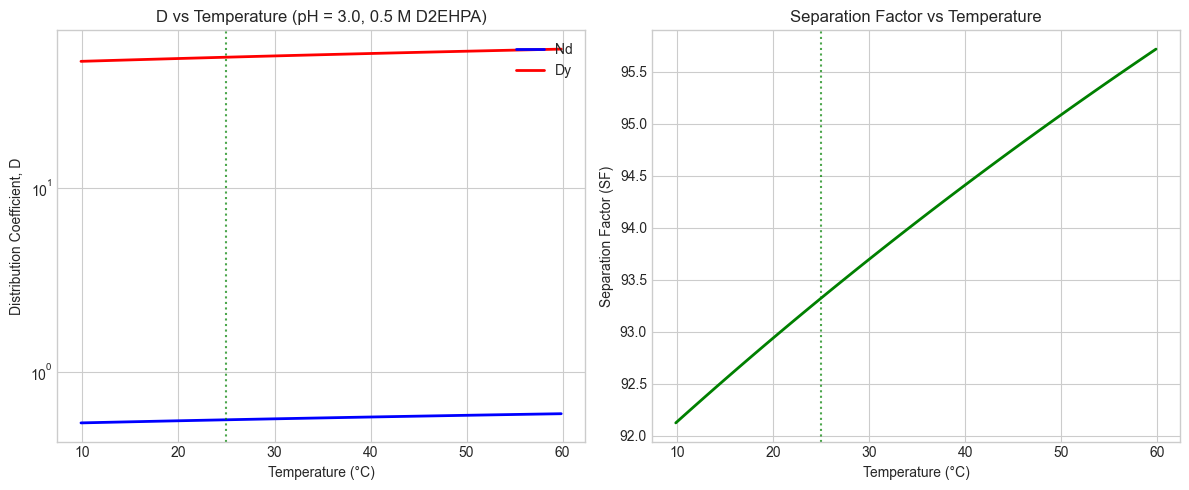

Temperature effect (pH=3, 0.5M D2EHPA):
  At 10°C: D_Nd=0.53, D_Dy=48.7, SF=92.1
  At 25°C: D_Nd=0.56, D_Dy=52.8, SF=94.0
  At 60°C: D_Nd=0.59, D_Dy=56.8, SF=95.7


In [4]:
# Temperature effect
T_vals = np.linspace(283, 333, 50)  # 10°C to 60°C
pH_fixed = 3.0

D_Nd_T = np.array([float(dist.get_D('Nd', pH_fixed, T)) for T in T_vals])
D_Dy_T = np.array([float(dist.get_D('Dy', pH_fixed, T)) for T in T_vals])
SF_T = D_Dy_T / D_Nd_T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: D vs Temperature
ax1 = axes[0]
ax1.semilogy(T_vals - 273.15, D_Nd_T, 'b-', linewidth=2, label='Nd')
ax1.semilogy(T_vals - 273.15, D_Dy_T, 'r-', linewidth=2, label='Dy')
ax1.axvline(x=25, color='green', linestyle=':', alpha=0.7)
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Distribution Coefficient, D')
ax1.set_title('D vs Temperature (pH = 3.0, 0.5 M D2EHPA)')
ax1.legend(loc='upper right')

# Right: SF vs Temperature
ax2 = axes[1]
ax2.plot(T_vals - 273.15, SF_T, 'g-', linewidth=2)
ax2.axvline(x=25, color='green', linestyle=':', alpha=0.7)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Separation Factor (SF)')
ax2.set_title('Separation Factor vs Temperature')

plt.tight_layout()
plt.show()

print(f"Temperature effect (pH=3, 0.5M D2EHPA):")
print(f"  At 10°C: D_Nd={D_Nd_T[0]:.2f}, D_Dy={D_Dy_T[0]:.1f}, SF={SF_T[0]:.1f}")
print(f"  At 25°C: D_Nd={D_Nd_T[24]:.2f}, D_Dy={D_Dy_T[24]:.1f}, SF={SF_T[24]:.1f}")
print(f"  At 60°C: D_Nd={D_Nd_T[-1]:.2f}, D_Dy={D_Dy_T[-1]:.1f}, SF={SF_T[-1]:.1f}")

## 4. Extractant Concentration Effect

Higher D2EHPA concentration increases D (more extractant available for complexation):

$$\log_{10}(D) \propto n \cdot \log_{10}([HA])$$

where n ≈ 3 for REE extraction with D2EHPA.

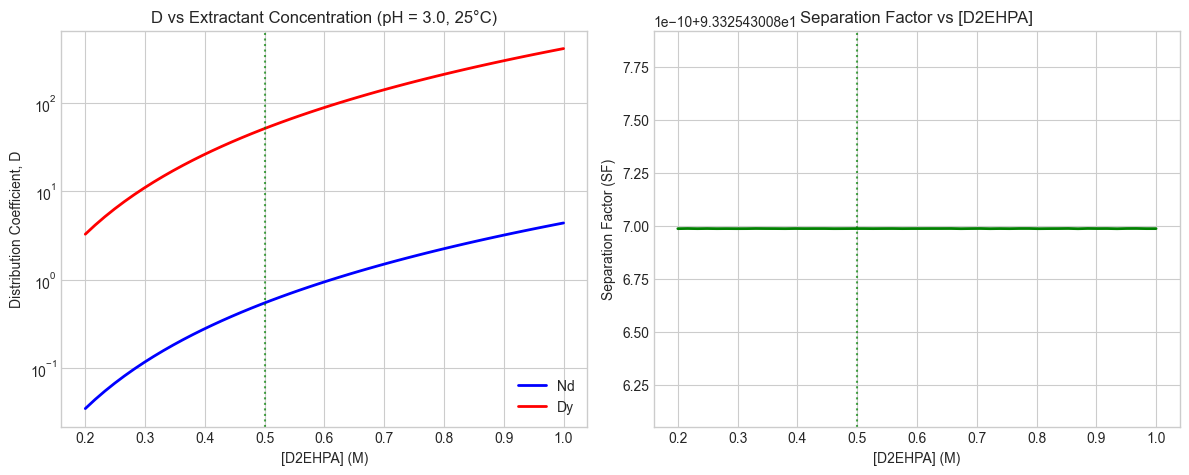

[D2EHPA] effect (pH=3, 25°C):
  At 0.2M: D_Nd=0.035, D_Dy=3.28, SF=93.3
  At 0.5M: D_Nd=0.91, D_Dy=85.1, SF=93.3
  At 1.0M: D_Nd=4.4, D_Dy=410, SF=93.3


In [5]:
# Concentration effect
conc_vals = np.linspace(0.2, 1.0, 50)

D_Nd_conc = []
D_Dy_conc = []
for c in conc_vals:
    dist_c = REEDistribution(extractant="D2EHPA", elements=("Nd", "Dy"), concentration=c)
    D_Nd_conc.append(float(dist_c.get_D('Nd', pH_fixed, T_ref)))
    D_Dy_conc.append(float(dist_c.get_D('Dy', pH_fixed, T_ref)))

D_Nd_conc = np.array(D_Nd_conc)
D_Dy_conc = np.array(D_Dy_conc)
SF_conc = D_Dy_conc / D_Nd_conc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: D vs [D2EHPA]
ax1 = axes[0]
ax1.semilogy(conc_vals, D_Nd_conc, 'b-', linewidth=2, label='Nd')
ax1.semilogy(conc_vals, D_Dy_conc, 'r-', linewidth=2, label='Dy')
ax1.axvline(x=0.5, color='green', linestyle=':', alpha=0.7)
ax1.set_xlabel('[D2EHPA] (M)')
ax1.set_ylabel('Distribution Coefficient, D')
ax1.set_title('D vs Extractant Concentration (pH = 3.0, 25°C)')
ax1.legend(loc='lower right')

# Right: SF vs [D2EHPA]
ax2 = axes[1]
ax2.plot(conc_vals, SF_conc, 'g-', linewidth=2)
ax2.axvline(x=0.5, color='green', linestyle=':', alpha=0.7)
ax2.set_xlabel('[D2EHPA] (M)')
ax2.set_ylabel('Separation Factor (SF)')
ax2.set_title('Separation Factor vs [D2EHPA]')

plt.tight_layout()
plt.show()

print(f"[D2EHPA] effect (pH=3, 25°C):")
print(f"  At 0.2M: D_Nd={D_Nd_conc[0]:.3f}, D_Dy={D_Dy_conc[0]:.2f}, SF={SF_conc[0]:.1f}")
print(f"  At 0.5M: D_Nd={D_Nd_conc[24]:.2f}, D_Dy={D_Dy_conc[24]:.1f}, SF={SF_conc[24]:.1f}")
print(f"  At 1.0M: D_Nd={D_Nd_conc[-1]:.1f}, D_Dy={D_Dy_conc[-1]:.0f}, SF={SF_conc[-1]:.1f}")

## 5. Combined Effect: 2D Contour Plots

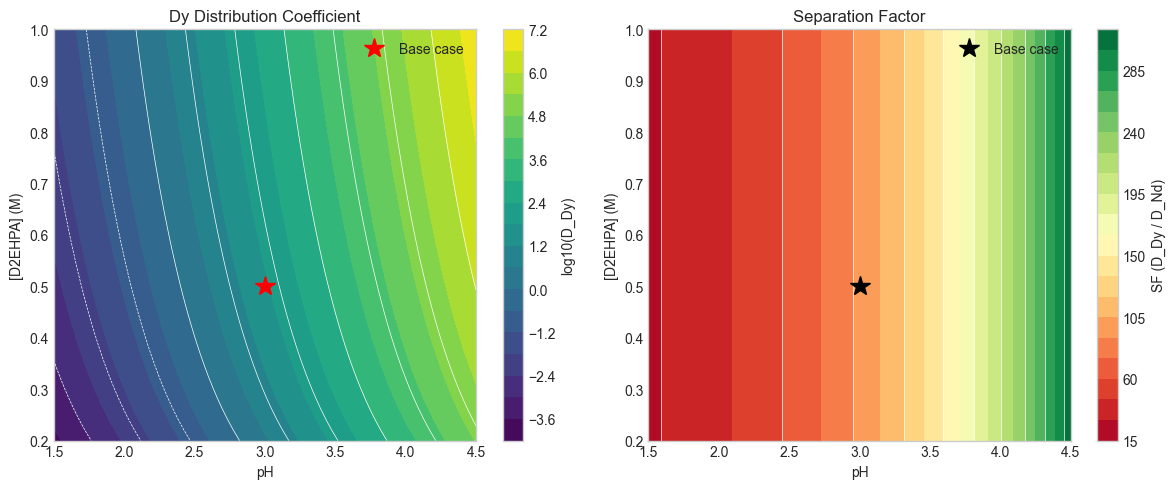

In [6]:
# Create 2D contour plot of SF vs pH and [D2EHPA]
pH_grid = np.linspace(1.5, 4.5, 40)
conc_grid = np.linspace(0.2, 1.0, 40)
pH_2d, conc_2d = np.meshgrid(pH_grid, conc_grid)

SF_2d = np.zeros_like(pH_2d)
D_Dy_2d = np.zeros_like(pH_2d)

for i in range(pH_2d.shape[0]):
    for j in range(pH_2d.shape[1]):
        dist_ij = REEDistribution(extractant="D2EHPA", elements=("Nd", "Dy"), concentration=conc_2d[i,j])
        D_Nd_ij = float(dist_ij.get_D('Nd', pH_2d[i,j], T_ref))
        D_Dy_ij = float(dist_ij.get_D('Dy', pH_2d[i,j], T_ref))
        SF_2d[i,j] = D_Dy_ij / D_Nd_ij
        D_Dy_2d[i,j] = D_Dy_ij

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: D_Dy contours
ax1 = axes[0]
cs1 = ax1.contourf(pH_2d, conc_2d, np.log10(D_Dy_2d), levels=20, cmap='viridis')
ax1.contour(pH_2d, conc_2d, np.log10(D_Dy_2d), levels=10, colors='white', linewidths=0.5)
cbar1 = plt.colorbar(cs1, ax=ax1)
cbar1.set_label('log10(D_Dy)')
ax1.plot(3.0, 0.5, 'r*', markersize=15, label='Base case')
ax1.set_xlabel('pH')
ax1.set_ylabel('[D2EHPA] (M)')
ax1.set_title('Dy Distribution Coefficient')
ax1.legend()

# Right: Separation Factor contours
ax2 = axes[1]
cs2 = ax2.contourf(pH_2d, conc_2d, SF_2d, levels=20, cmap='RdYlGn')
ax2.contour(pH_2d, conc_2d, SF_2d, levels=10, colors='white', linewidths=0.5)
cbar2 = plt.colorbar(cs2, ax=ax2)
cbar2.set_label('SF (D_Dy / D_Nd)')
ax2.plot(3.0, 0.5, 'k*', markersize=15, label='Base case')
ax2.set_xlabel('pH')
ax2.set_ylabel('[D2EHPA] (M)')
ax2.set_title('Separation Factor')
ax2.legend()

plt.tight_layout()
plt.show()

## Summary

**Key findings:**

1. **pH is the dominant factor** affecting D values
   - D increases exponentially with pH
   - Separation factor varies with pH due to different element-specific slopes

2. **Temperature has moderate effect**
   - D decreases with increasing temperature (exothermic extraction)
   - Lower temperature favors both extraction and separation

3. **[D2EHPA] concentration strongly affects D**
   - D ∝ [D2EHPA]³
   - Separation factor relatively unchanged (both D values scale similarly)

**difflow_ree advantage:** All distribution coefficient calculations are JAX-differentiable, enabling gradient-based optimization of operating conditions.

**Next:** In notebook 03, we'll use automatic differentiation to compute exact sensitivities of purity and recovery to these parameters.